# EXP-07: ML VAD
Feature comparison: four development tables (LR/RF × AUC/miss). Test summary: three mixed-scene metric tables and a separate noise-only FAR table.
Audit: tables reformatted from saved CSVs, without retraining. Noise-only balanced accuracy is undefined. Context and smoothing use future frames (offline evaluation). Babble is background speech; these rows measure foreground activity, not all audible speech.


In [1]:
import sys; sys.path.append("../src")
import os, time
import numpy as np, pandas as pd, matplotlib.pyplot as plt, joblib
import config as cfg, vad_core as vc, vad_data as vd
print("Setup OK | number of features:", len(vc.FEATURE_NAMES))

Setup OK | number of features: 19


In [2]:
corpus = vd.load_corpus()
for part in ["train_clean", "test_clean"]:
    vd.prepare_clean(corpus[part])                      # adds gaps before/after each utterance and frame labels

train_items, dev_items = vd.split_dev(corpus["train_clean"])
train_noise, dev_noise = vd.split_dev(corpus["train_noise"])

print({name: len(items) for name, items in corpus.items()})
print("Train utterances:", len(train_items), "| Dev utterances:", len(dev_items))
print("Speech share after adding gaps:", np.mean([item["labels"].mean() for item in train_items]).round(2))

c:\Users\Esma Nur Mantı\Desktop\vad-research\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
c:\Users\Esma Nur Mantı\Desktop\vad-research\.venv\Lib\site-packages\huggingface_hub\file_download.py:149: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\Esma Nur Mantı\.cache\huggingface\hub\datasets--Aynursusuz--noisy-speech-dataset. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Py

{'train_clean': 40, 'train_noise': 40, 'test_clean': 20, 'test_noise': 20}
Train utterances: 30 | Dev utterances: 10
Speech share after adding gaps: 0.79


In [4]:
import warnings
warnings.filterwarnings("ignore")

In [5]:
train_clean_only = vd.build_records(train_items, {})
train_noise_aware = (train_clean_only
                     + vd.build_records(train_items, {"snr": (0, 20)}, train_noise, seed=1)
                     + vd.build_records(train_items, {"snr": (0, 20)}, train_noise, seed=2)
                     + vd.noise_records(train_noise))

dev_sets = {
    "clean": vd.build_records(dev_items, {}),
    "snr 20": vd.build_records(dev_items, {"snr": 20}, dev_noise),
    "snr 10": vd.build_records(dev_items, {"snr": 10}, dev_noise),
    "snr 0": vd.build_records(dev_items, {"snr": 0}, dev_noise),
}
dev_all = sum(dev_sets.values(), [])

frames = lambda records: sum(len(r["y"]) for r in records)
print("Training frames - clean only:", frames(train_clean_only), "| noise-aware:", frames(train_noise_aware))
print("Dev frames:", frames(dev_all))

Training frames - clean only: 72432 | noise-aware: 277236
Dev frames: 96048


In [ ]:
FEATURE_SETS = {
    "absolute energy": ["energy_abs"],
    "relative energy": ["energy_rel"],
    "relative energy + zcr": ["energy_rel", "zcr"],
    "relative energy + zcr + spectral": ["energy_rel", "zcr", "spectral"],
    "relative energy + zcr + spectral + mfcc": ["energy_rel", "zcr", "spectral", "mfcc"],
    "all (absolute + relative + rest)": ["energy_abs", "energy_rel", "zcr", "spectral", "mfcc"],
    "no energy (zcr + spectral + mfcc)": ["zcr", "spectral", "mfcc"],
}

rows = []
for name, groups in FEATURE_SETS.items():
    for kind in ["lr", "rf"]:
        spec = vd.fit(kind, train_noise_aware, groups)
        rows.append({"features": name, "model": kind, "AUC": vd.auc(spec, dev_all),
                     "miss at 5% false alarm": vd.miss_at_far(spec, dev_all)})
ablation = pd.DataFrame(rows)
# Four explicit tables: 2 models x 2 metrics, all on development data.
for kind in ["lr", "rf"]:
    for metric in ["AUC", "miss at 5% false alarm"]:
        print(f"Development — {kind.upper()} — {metric}")
        table = ablation[ablation["model"] == kind].set_index("features")[[metric]].loc[list(FEATURE_SETS)]
        display(table.round(3))


Development — LR — AUC
Development — LR — miss at 5% false alarm
Development — RF — AUC
Development — RF — miss at 5% false alarm


,AUC
features,
absolute energy,0.833
relative energy,0.899
relative energy + zcr,0.904
relative energy + zcr + spectral,0.886
relative energy + zcr + spectral + mfcc,0.899
all (absolute + relative + rest),0.914
no energy (zcr + spectral + mfcc),0.814


,miss at 5% false alarm
features,
absolute energy,0.611
relative energy,0.453
relative energy + zcr,0.455
relative energy + zcr + spectral,0.476
relative energy + zcr + spectral + mfcc,0.430
all (absolute + relative + rest),0.312
no energy (zcr + spectral + mfcc),0.575


,AUC
features,
absolute energy,0.800
relative energy,0.893
relative energy + zcr,0.892
relative energy + zcr + spectral,0.913
relative energy + zcr + spectral + mfcc,0.927
all (absolute + relative + rest),0.939
no energy (zcr + spectral + mfcc),0.891


,miss at 5% false alarm
features,
absolute energy,0.627
relative energy,0.454
relative energy + zcr,0.469
relative energy + zcr + spectral,0.398
relative energy + zcr + spectral + mfcc,0.298
all (absolute + relative + rest),0.213
no energy (zcr + spectral + mfcc),0.323


In [7]:
BEST_GROUPS = ["energy_abs", "energy_rel", "zcr", "spectral", "mfcc"]     # best set on the development data

rows = []
for frame_ms in [20, 30, 40]:
    for items in [train_items, dev_items]:
        vd.prepare_clean(items, frame_ms=frame_ms)          # labels must match the frame size
    tr = (vd.build_records(train_items, {}, frame_ms=frame_ms)
          + vd.build_records(train_items, {"snr": (0, 20)}, train_noise, seed=1, frame_ms=frame_ms)
          + vd.noise_records(train_noise, frame_ms=frame_ms))
    dv = sum([vd.build_records(dev_items, cond, dev_noise, frame_ms=frame_ms)
              for cond in [{}, {"snr": 20}, {"snr": 10}, {"snr": 0}]], [])
    spec = vd.fit("lr", tr, BEST_GROUPS)
    rows.append({"frame_ms": frame_ms, "hop_ms": cfg.HOP_MS, "AUC": vd.auc(spec, dv),
                 "miss at 5% false alarm": vd.miss_at_far(spec, dv)})

for items in [train_items, dev_items]:
    vd.prepare_clean(items)                                 # restore the default frame size
display(pd.DataFrame(rows).round(3))

,frame_ms,hop_ms,AUC,miss at 5% false alarm
0,20,10,0.900,0.330
1,30,10,0.906,0.313
2,40,10,0.909,0.304


In [8]:
rows = []
context_specs = {}
for k in [0, 2, 5, 10]:
    spec = vd.fit("lr", train_noise_aware, BEST_GROUPS, context=k)
    context_specs[k] = spec
    rows.append({"setting": f"context +-{k} frames ({2 * k * cfg.HOP_MS + cfg.FRAME_MS} ms signal span)", "AUC": vd.auc(spec, dev_all),
                 "miss at 5% false alarm": vd.miss_at_far(spec, dev_all)})
for window in [11, 21, 31]:
    spec = dict(context_specs[0], smooth=window)
    rows.append({"setting": f"no context, score smoothing {window * cfg.HOP_MS} ms", "AUC": vd.auc(spec, dev_all),
                 "miss at 5% false alarm": vd.miss_at_far(spec, dev_all)})
display(pd.DataFrame(rows).round(3))

,setting,AUC,miss at 5% false alarm
0,context +-0 frames (30 ms signal span),0.914,0.312
1,context +-2 frames (70 ms signal span),0.928,0.278
2,context +-5 frames (130 ms signal span),0.941,0.243
3,context +-10 frames (230 ms signal span),0.953,0.199
4,"no context, score smoothing 110 ms",0.934,0.288
5,"no context, score smoothing 210 ms",0.946,0.248
6,"no context, score smoothing 310 ms",0.954,0.214


In [9]:
rows = []
for k in [5, 10]:
    for window in [1, 11, 21, 31]:
        spec = dict(context_specs[k], smooth=window)
        rows.append({"context (frames)": k, "smoothing (ms)": window * cfg.HOP_MS,
                     "miss at 5% false alarm": vd.miss_at_far(spec, dev_all)})
display(pd.DataFrame(rows).pivot(index="context (frames)", columns="smoothing (ms)",
                                 values="miss at 5% false alarm").round(3))

smoothing (ms),10,110,210,310
context (frames),,,,
5,0.243,0.220,0.195,0.181
10,0.199,0.178,0.168,0.162


In [10]:
BEST_CONTEXT = 5        # set from the table above
BEST_SMOOTH = 21        # in frames: 21 = 210 ms, 31 = 310 ms

LEVEL_FREE = ["energy_rel", "zcr", "spectral", "mfcc"]      # the same set without absolute energy

def build(kind, train_set, groups):
    """Train, add score smoothing and set the threshold for 5% false alarms on the development set."""
    spec = vd.fit(kind, train_set, groups, context=BEST_CONTEXT)
    spec["smooth"] = BEST_SMOOTH
    return vd.calibrate(spec, dev_all)

models = {
    "LR, clean only": build("lr", train_clean_only, BEST_GROUPS),
    "LR, noise-aware": build("lr", train_noise_aware, BEST_GROUPS),
    "RF, clean only": build("rf", train_clean_only, BEST_GROUPS),
    "RF, noise-aware": build("rf", train_noise_aware, BEST_GROUPS),
    "RF, noise-aware, no absolute energy": build("rf", train_noise_aware, LEVEL_FREE),
    "robust threshold + hangover 200 ms": {"kind": "robust_threshold", "extend": (0, 200 // cfg.HOP_MS)},
    "WebRTC VAD (mode 2)": {"kind": "webrtc", "mode": 2},
}
for name, spec in models.items():
    if "threshold" in spec:
        print(f"{name}: decision threshold = {spec['threshold']:.3f}")

LR, clean only: decision threshold = 1.000
LR, noise-aware: decision threshold = 0.724
RF, clean only: decision threshold = 0.988
RF, noise-aware: decision threshold = 0.755
RF, noise-aware, no absolute energy: decision threshold = 0.726


In [12]:
%pip install webrtcvad-wheels

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [13]:

TEST_CONDITIONS = {
    "clean": {},
    "snr 20": {"snr": 20}, "snr 10": {"snr": 10}, "snr 5": {"snr": 5}, "snr 0": {"snr": 0},
    "white 10": {"snr": 10, "noise": "white"},
    "pink 10": {"snr": 10, "noise": "pink"},
    "babble 5": {"snr": 5, "noise": "babble"},
    "reverb": {"reverb": 0.6},
    "reverb + snr 10": {"reverb": 0.6, "snr": 10},
    "telephone + snr 10": {"snr": 10, "telephone": True},
    "quiet (-20 dB) + snr 10": {"snr": 10, "gain": -20},
}

rows = []
for cond_name, cond in TEST_CONDITIONS.items():
    records = vd.build_records(corpus["test_clean"], cond, corpus["test_noise"], keep_audio=True)
    for model_name, spec in models.items():
        rows.append({"model": model_name, "condition": cond_name, **vd.evaluate(spec, records)})
    del records

noise_only = vd.noise_records(corpus["test_noise"], keep_audio=True)
for model_name, spec in models.items():
    rows.append({"model": model_name, "condition": "noise only", **vd.evaluate(spec, noise_only)})
test_results = pd.DataFrame(rows)
print("Done:", len(test_results), "rows")

Done: 91 rows


In [ ]:
order = list(TEST_CONDITIONS)
for value in ["balanced_acc", "miss_rate", "false_alarm_rate"]:
    print(value)
    display(test_results[test_results["condition"] != "noise only"].pivot(
        index="model", columns="condition", values=value).loc[list(models), order].round(3))
print("False alarm rate on noise-only recordings")
display(test_results[test_results["condition"] == "noise only"].set_index("model")[["false_alarm_rate"]].round(3))


balanced_acc
miss_rate
false_alarm_rate
False alarm rate on noise-only recordings


condition,clean,snr 20,snr 10,snr 5,snr 0,white 10,pink 10,babble 5,reverb,reverb + snr 10,telephone + snr 10,quiet (-20 dB) + snr 10
model,,,,,,,,,,,,
"LR, clean only",0.655,0.643,0.651,0.686,0.667,0.549,0.630,0.800,0.700,0.693,0.500,0.500
"LR, noise-aware",0.936,0.892,0.849,0.827,0.818,0.860,0.769,0.844,0.941,0.875,0.740,0.534
"RF, clean only",0.901,0.887,0.802,0.718,0.623,0.596,0.752,0.840,0.946,0.857,0.701,0.727
"RF, noise-aware",0.959,0.907,0.912,0.904,0.896,0.790,0.875,0.821,0.949,0.918,0.750,0.532
"RF, noise-aware, no absolute energy",0.961,0.936,0.899,0.825,0.692,0.695,0.840,0.838,0.944,0.895,0.860,0.899
robust threshold + hangover 200 ms,0.913,0.839,0.738,0.687,0.628,0.937,0.639,0.801,0.895,0.757,0.729,0.738
WebRTC VAD (mode 2),0.883,0.915,0.536,0.500,0.500,0.910,0.874,0.560,0.914,0.535,0.760,0.903


condition,clean,snr 20,snr 10,snr 5,snr 0,white 10,pink 10,babble 5,reverb,reverb + snr 10,telephone + snr 10,quiet (-20 dB) + snr 10
model,,,,,,,,,,,,
"LR, clean only",0.690,0.715,0.684,0.594,0.281,0.902,0.740,0.369,0.601,0.603,0.999,1.000
"LR, noise-aware",0.129,0.215,0.299,0.338,0.326,0.280,0.081,0.062,0.090,0.238,0.519,0.931
"RF, clean only",0.198,0.221,0.389,0.562,0.750,0.808,0.487,0.207,0.087,0.274,0.596,0.545
"RF, noise-aware",0.079,0.184,0.176,0.112,0.163,0.419,0.189,0.036,0.059,0.156,0.500,0.935
"RF, noise-aware, no absolute energy",0.063,0.118,0.201,0.348,0.614,0.610,0.318,0.113,0.039,0.200,0.273,0.201
robust threshold + hangover 200 ms,0.001,0.019,0.030,0.032,0.033,0.049,0.020,0.042,0.007,0.039,0.036,0.030
WebRTC VAD (mode 2),0.024,0.063,0.006,0.000,0.000,0.129,0.117,0.000,0.031,0.005,0.051,0.155


condition,clean,snr 20,snr 10,snr 5,snr 0,white 10,pink 10,babble 5,reverb,reverb + snr 10,telephone + snr 10,quiet (-20 dB) + snr 10
model,,,,,,,,,,,,
"LR, clean only",0.000,0.000,0.013,0.033,0.385,0.000,0.000,0.030,0.000,0.010,0.000,0.000
"LR, noise-aware",0.000,0.002,0.003,0.008,0.038,0.000,0.381,0.249,0.028,0.012,0.000,0.000
"RF, clean only",0.000,0.005,0.008,0.002,0.004,0.000,0.009,0.112,0.021,0.012,0.003,0.000
"RF, noise-aware",0.003,0.002,0.001,0.079,0.045,0.000,0.060,0.323,0.042,0.008,0.000,0.000
"RF, noise-aware, no absolute energy",0.016,0.010,0.002,0.001,0.001,0.000,0.002,0.212,0.074,0.010,0.007,0.002
robust threshold + hangover 200 ms,0.173,0.302,0.495,0.594,0.711,0.076,0.702,0.357,0.204,0.447,0.505,0.495
WebRTC VAD (mode 2),0.210,0.106,0.921,1.000,1.000,0.051,0.135,0.880,0.141,0.925,0.430,0.039


,false_alarm_rate
model,
"LR, clean only",0.012
"LR, noise-aware",0.021
"RF, clean only",0.261
"RF, noise-aware",0.020
"RF, noise-aware, no absolute energy",0.030
robust threshold + hangover 200 ms,0.950
WebRTC VAD (mode 2),0.821


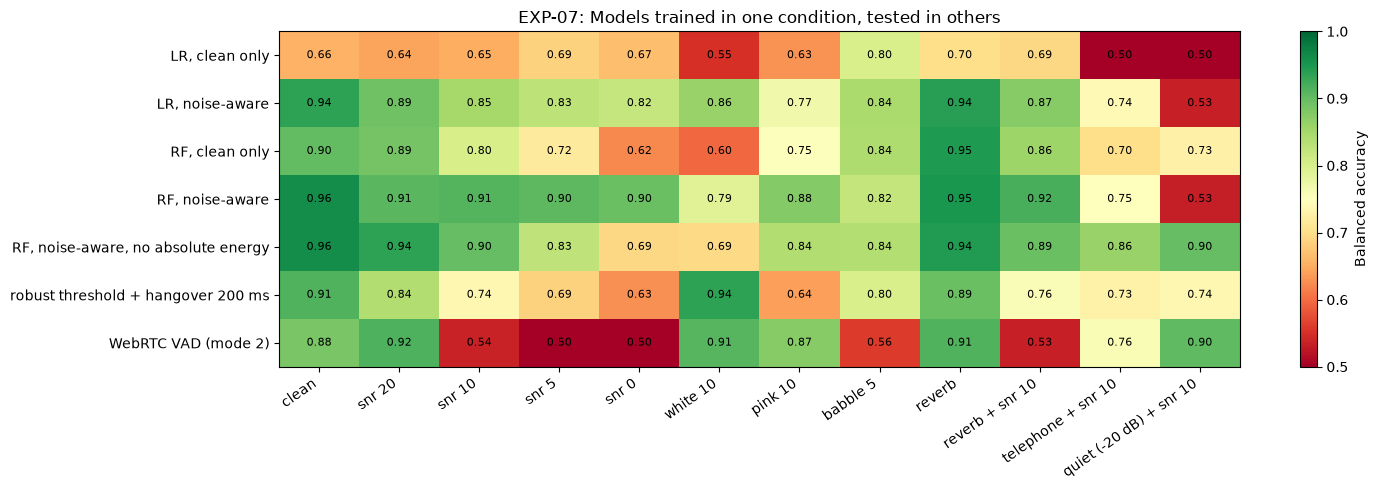

In [15]:
matrix = test_results[test_results["condition"] != "noise only"].pivot(
    index="model", columns="condition", values="balanced_acc").loc[list(models), order]

fig, ax = plt.subplots(figsize=(15, 5))
image = ax.imshow(matrix.values, cmap="RdYlGn", vmin=0.5, vmax=1.0, aspect="auto")
ax.set_xticks(range(len(order))); ax.set_xticklabels(order, rotation=35, ha="right")
ax.set_yticks(range(len(matrix))); ax.set_yticklabels(matrix.index)
for i in range(matrix.shape[0]):
    for j in range(matrix.shape[1]):
        ax.text(j, i, f"{matrix.values[i, j]:.2f}", ha="center", va="center", fontsize=8)
plt.colorbar(image, label="Balanced accuracy")
plt.title("EXP-07: Models trained in one condition, tested in others"); plt.tight_layout(); plt.show()

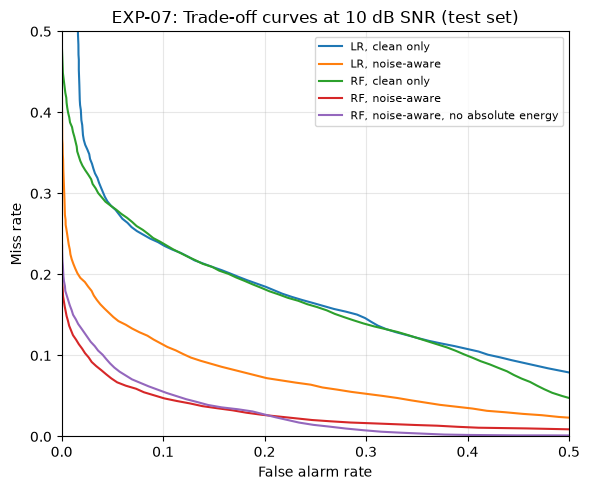

In [16]:
records = vd.build_records(corpus["test_clean"], {"snr": 10}, corpus["test_noise"])
plt.figure(figsize=(6, 5))
for model_name, spec in models.items():
    if spec["kind"] in ("lr", "rf"):
        y_true, score = vd.pooled_scores(spec, records)
        far, miss = vc.det_points(y_true, score)
        plt.plot(far, miss, label=model_name)
plt.xlabel("False alarm rate"); plt.ylabel("Miss rate"); plt.xlim(0, 0.5); plt.ylim(0, 0.5)
plt.title("EXP-07: Trade-off curves at 10 dB SNR (test set)"); plt.legend(fontsize=8); plt.grid(alpha=0.3)
plt.tight_layout(); plt.show()

In [17]:
names = vc.select_features(dev_all[0]["X"], BEST_GROUPS)[1]
forest = vd.fit("rf", train_noise_aware, BEST_GROUPS)["model"]         # without context, so one value per feature
importance = pd.Series(forest.feature_importances_, index=names).sort_values(ascending=False)
display(importance.head(10).round(3))

record = records[0]
seconds = len(record["y"]) * cfg.HOP_MS / 1000
rows = []
for model_name, spec in models.items():
    if spec["kind"] == "webrtc":
        continue
    start = time.perf_counter()
    for _ in range(5):
        vd.predict(spec, record)
    rows.append({"model": model_name, "ms per second of audio": (time.perf_counter() - start) / 5 / seconds * 1000})
display(pd.DataFrame(rows).round(2))

rms_db      0.312
rms_rel     0.294
mfcc3       0.079
mfcc1       0.052
flatness    0.044
mfcc4       0.028
centroid    0.026
mfcc5       0.026
mfcc2       0.024
rolloff     0.021
dtype: float64

,model,ms per second of audio
0,"LR, clean only",0.17
1,"LR, noise-aware",0.17
2,"RF, clean only",1.23
3,"RF, noise-aware",1.30
4,"RF, noise-aware, no absolute energy",1.22
5,robust threshold + hangover 200 ms,0.01


In [18]:
os.makedirs(cfg.RESULTS_DIR, exist_ok=True)
ablation.to_csv(os.path.join(cfg.RESULTS_DIR, "exp07_feature_ablation.csv"), index=False)
test_results.to_csv(os.path.join(cfg.RESULTS_DIR, "exp07_condition_matrix.csv"), index=False)
os.makedirs("../models", exist_ok=True)
for model_name, spec in models.items():
    if spec["kind"] in ("lr", "rf"):
        joblib.dump(spec, os.path.join("../models", model_name.replace(", ", "_").replace(" ", "_").replace("-", "_") + ".joblib"))
print("Saved.")
# Export the four development feature tables and four test summary tables.
for kind in ["lr", "rf"]:
    for metric, slug in [("AUC", "auc"), ("miss at 5% false alarm", "miss")]:
        ablation[ablation["model"] == kind].set_index("features")[[metric]].to_csv(
            os.path.join(cfg.RESULTS_DIR, f"exp07_feature_{kind}_{slug}_dev.csv"))
for metric in ["balanced_acc", "miss_rate", "false_alarm_rate"]:
    test_results[test_results["condition"] != "noise only"].pivot(
        index="model", columns="condition", values=metric).to_csv(
        os.path.join(cfg.RESULTS_DIR, f"exp07_test_{metric}.csv"))
test_results[test_results["condition"] == "noise only"].set_index("model")[["false_alarm_rate"]].to_csv(
    os.path.join(cfg.RESULTS_DIR, "exp07_test_noise_only_far.csv"))


Saved.
